# Práctica de Redes Neuronales: Diseño de Arquitecturas Densas
## Actividad colaborativa

En este notebook probamos tres arquitecturas distintas para el mismo problema de clasificación, con la idea de entender qué efecto tiene cada decisión de diseño (número de capas, activación, optimizador, regularización) sobre el entrenamiento. No se trata solo de que las redes funcionen, sino de poder explicar por qué se comportan como se comportan.

## 1. Equipo y roles

| Integrante | Rol | Aporte principal |
|---|---|---|
| Jose Alejandro Alvarenga Guerra | Arquitecto de Red | Definición de las tres arquitecturas: capas, neuronas y activaciones |
| César Eduardo Navarrete Chavarría | Especialista en Datos y Analista de Métricas | Preparación del dataset, split train/val/test, escalado, función de graficado y lectura de resultados |

Como equipo acordamos:
- Usar el dataset Digits de scikit-learn porque no requiere descargas externas y permite iterar rápido.
- Entrenar con solo 300 muestras a propósito, para que el overfitting se note dentro de las 150 épocas que usamos.
- Fijar una semilla común (SEED = 42) para que ambos pudiéramos reproducir resultados parecidos en nuestras máquinas.
- Comparar los tres modelos con las mismas particiones de datos y la misma función de graficado, para que la comparación fuera justa.

## 2. Configuración inicial

Antes de armar los modelos fijamos las semillas de numpy, random y TensorFlow. Es un detalle importante en un trabajo de equipo: si cada integrante corre el notebook en su computadora, todos deberían llegar a resultados parecidos.

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

plt.rcParams["figure.figsize"] = (7, 4)
print("TensorFlow:", tf.__version__)

# Evidencia de los integrantes
print("\n--- Práctica realizada por: ---")
print("- Jose Alejandro Alvarenga Guerra")
print("- César Eduardo Navarrete Chavarría")
print("-------------------------------\n")


/Users/alejandroalvarenga/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TensorFlow: 2.20.0

--- Práctica realizada por: ---
- Jose Alejandro Alvarenga Guerra
- César Eduardo Navarrete Chavarría
-------------------------------



## Fase 1: Construcción de las arquitecturas

### El problema que vamos a resolver

Trabajamos con el dataset Digits de scikit-learn: imágenes de 8x8 píxeles (64 valores) de dígitos del 0 al 9, es decir 10 clases. Lo elegimos porque viene incluido en scikit-learn, entrena rápido y es fácil de visualizar.

Para que el overfitting se note con claridad, entrenamos con muy pocas muestras (300) frente a la cantidad de parámetros que van a tener los modelos B y C. Esa decisión es intencional: buscamos que la brecha entre entrenamiento y validación aparezca dentro del rango de épocas que estamos usando.

Forma de X: (1797, 64) | Clases: [0 1 2 3 4 5 6 7 8 9]


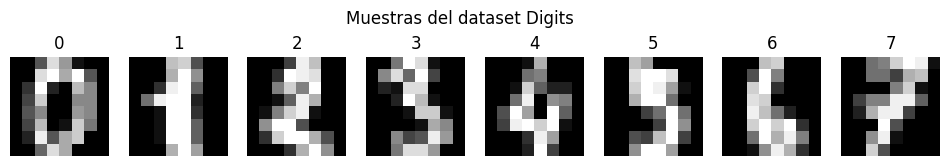

In [2]:
digits = load_digits()
X, y = digits.data, digits.target
print("Forma de X:", X.shape, "| Clases:", np.unique(y))

# Vista rápida de algunas muestras
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap="gray")
    ax.set_title(str(digits.target[i]))
    ax.axis("off")
plt.suptitle("Muestras del dataset Digits")
plt.show()

In [3]:
# Split: 300 muestras para entrenar (para forzar overfitting en modelos grandes),
# el resto se reparte entre validación y prueba.
X_train, X_rest, y_train, y_rest = train_test_split(
    X, y, train_size=300, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_rest, y_rest, test_size=0.5, stratify=y_rest, random_state=SEED
)

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

Train: 300 | Val: 748 | Test: 749


In [4]:
def plot_history(history, title):
    hist = history.history
    epochs_range = range(1, len(hist["loss"]) + 1)
    best_epoch = int(np.argmin(hist["val_loss"])) + 1

    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    axs[0].plot(epochs_range, hist["loss"], label="Loss (train)")
    axs[0].plot(epochs_range, hist["val_loss"], label="Loss (val)")
    axs[0].axvline(best_epoch, color="red", linestyle="--", alpha=0.7,
                    label=f"Punto de overfitting (época {best_epoch})")
    axs[0].set_title(f"{title} — Loss")
    axs[0].set_xlabel("Época"); axs[0].set_ylabel("Loss"); axs[0].legend()

    axs[1].plot(epochs_range, hist["accuracy"], label="Accuracy (train)")
    axs[1].plot(epochs_range, hist["val_accuracy"], label="Accuracy (val)")
    axs[1].axvline(best_epoch, color="red", linestyle="--", alpha=0.7)
    axs[1].set_title(f"{title} — Accuracy")
    axs[1].set_xlabel("Época"); axs[1].set_ylabel("Accuracy"); axs[1].legend()

    plt.tight_layout()
    plt.show()

    print(f"-> Mínimo val_loss = {hist['val_loss'][best_epoch-1]:.4f} en la época {best_epoch}/{len(hist['loss'])}")
    print(f"-> Accuracy final  -> train: {hist['accuracy'][-1]:.3f} | val: {hist['val_accuracy'][-1]:.3f}"
          f" | brecha (gap): {hist['accuracy'][-1]-hist['val_accuracy'][-1]:.3f}")
    return best_epoch

### Modelo A — El Minimalista

Una sola capa oculta de 8 neuronas con activación sigmoid, entrenada con SGD. La elegimos como línea base intencionalmente pequeña: con tan pocos parámetros el riesgo de overfitting es bajo, pero corre el riesgo contrario (underfitting) si la capacidad no alcanza para separar bien las 10 clases. Usamos sigmoid porque en una sola capa no arrastra el problema de gradiente que sí aparece en redes más profundas (lo vemos en el Modelo B).

In [5]:
model_a = keras.Sequential([
    layers.Input(shape=(64,)),
    layers.Dense(8, activation="sigmoid"),
    layers.Dense(10, activation="softmax")
], name="Modelo_A_Minimalista")

model_a.compile(optimizer=keras.optimizers.SGD(learning_rate=0.1),
                 loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model_a.summary()

Model: "Modelo_A_Minimalista"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │            90 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 610 (2.38 KB)

 Trainable params: 610 (2.38 KB)

 Non-trainable params: 0 (0.00 B)

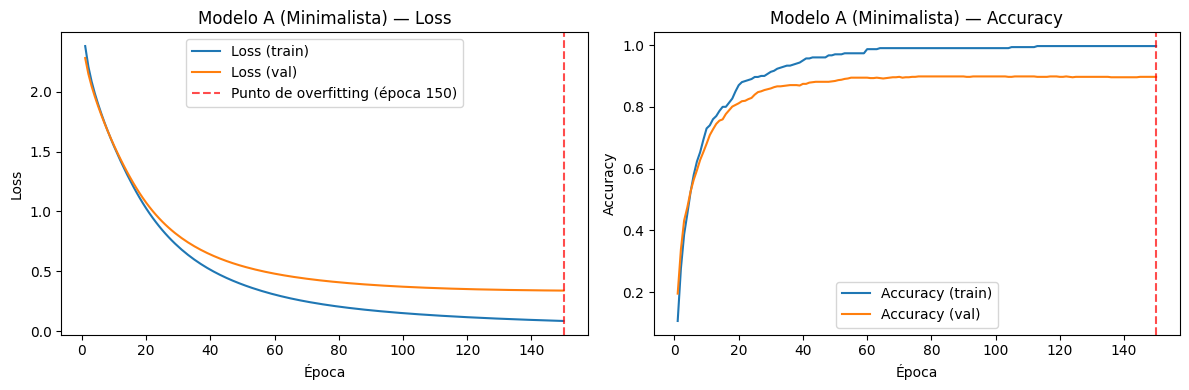

-> Mínimo val_loss = 0.3381 en la época 150/150
-> Accuracy final  -> train: 0.997 | val: 0.897 | brecha (gap): 0.100


In [6]:
history_a = model_a.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=150, batch_size=16, verbose=0
)
best_epoch_a = plot_history(history_a, "Modelo A (Minimalista)")

### Modelo B — El Profundo

Cuatro capas ocultas (256, 256, 128 y 64 neuronas) con activación relu, el mismo optimizador SGD que el Modelo A y sin ningún mecanismo de regularización. Cambiamos la activación a relu porque en una red de varias capas sigmoid tiende a saturar el gradiente y frena el aprendizaje de las primeras capas. Esta arquitectura tiene muchísima más capacidad que las 300 muestras de entrenamiento disponibles, así que es la que esperamos que sobreajuste más rápido.

In [7]:
model_b = keras.Sequential([
    layers.Input(shape=(64,)),
    layers.Dense(256, activation="relu"),
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
], name="Modelo_B_Profundo")

model_b.compile(optimizer=keras.optimizers.SGD(learning_rate=0.1),
                 loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model_b.summary()

Model: "Modelo_B_Profundo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,234 (485.29 KB)

 Trainable params: 124,234 (485.29 KB)

 Non-trainable params: 0 (0.00 B)

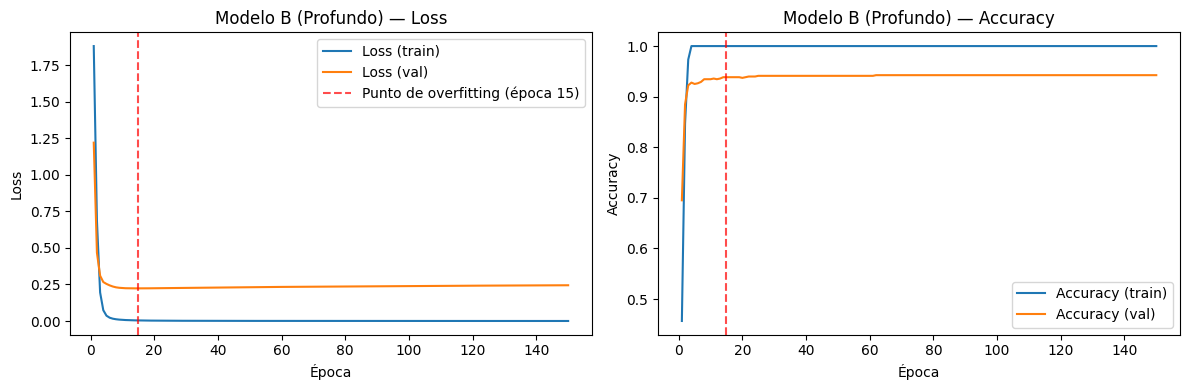

-> Mínimo val_loss = 0.2234 en la época 15/150
-> Accuracy final  -> train: 1.000 | val: 0.943 | brecha (gap): 0.057


In [8]:
history_b = model_b.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=150, batch_size=16, verbose=0
)
best_epoch_b = plot_history(history_b, "Modelo B (Profundo)")

### Modelo C — El Optimizado

Dos capas ocultas (128 y 64 neuronas) con relu, regularización L2 (1e-4) en ambas capas densas, Dropout (0.4 y 0.3) después de cada una, y Adam en lugar de SGD. La idea de diseño es reducir la brecha train-val que vimos en el Modelo B sin perder tanta capacidad de representación: L2 penaliza pesos grandes, Dropout evita que la red dependa de neuronas específicas, y Adam ajusta el learning rate de forma más eficiente que un SGD plano.

In [9]:
model_c = keras.Sequential([
    layers.Input(shape=(64,)),
    layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.4),
    layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
], name="Modelo_C_Optimizado")

model_c.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                 loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model_c.summary()

Model: "Modelo_C_Optimizado"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,226 (67.29 KB)

 Trainable params: 17,226 (67.29 KB)

 Non-trainable params: 0 (0.00 B)

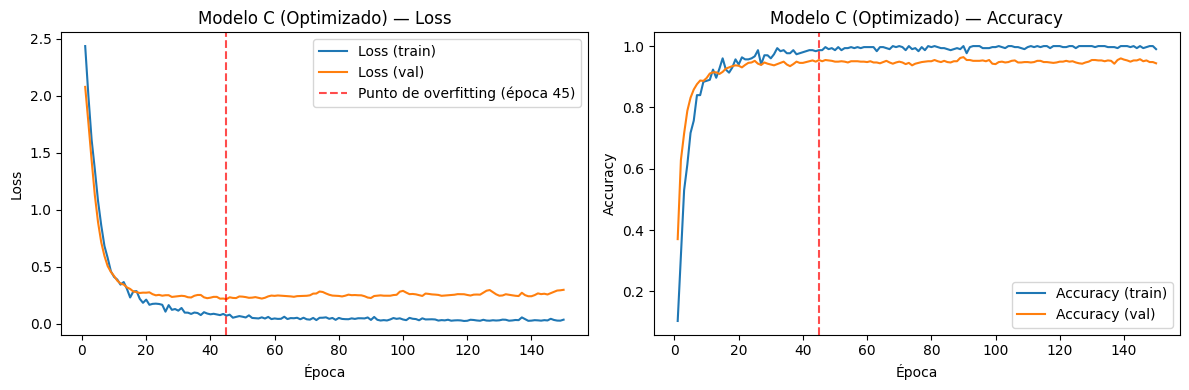

-> Mínimo val_loss = 0.2161 en la época 45/150
-> Accuracy final  -> train: 0.990 | val: 0.944 | brecha (gap): 0.046


In [10]:
history_c = model_c.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=150, batch_size=16, verbose=0
)
best_epoch_c = plot_history(history_c, "Modelo C (Optimizado)")

## Fase 2: Monitoreo y mesa de auditoría

### Comparación conjunta de las curvas de Loss y Accuracy

Antes de sacar conclusiones por separado, superponemos las curvas de los tres modelos para discutirlas juntos como equipo.

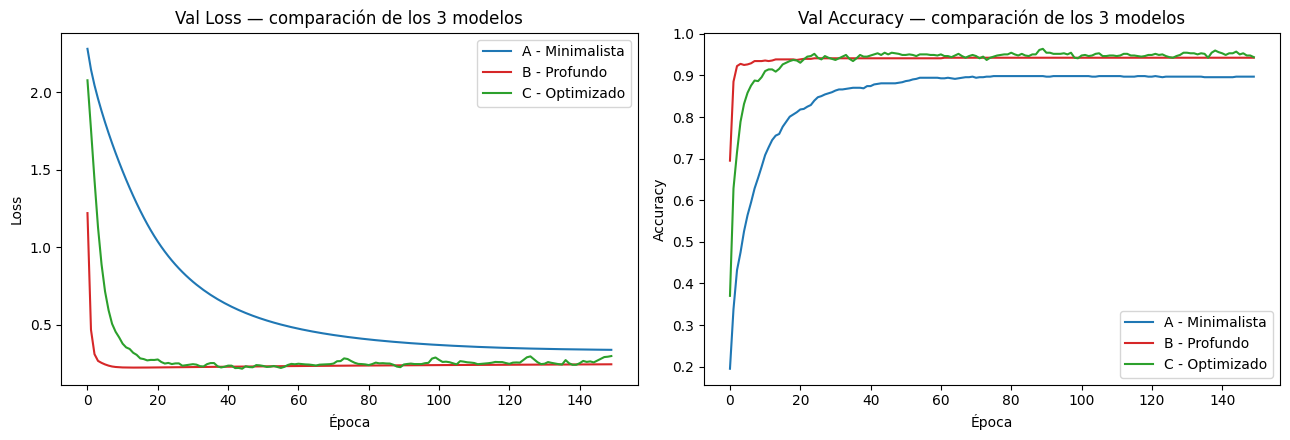

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
for hist, name, color in [
    (history_a.history, "A - Minimalista", "tab:blue"),
    (history_b.history, "B - Profundo", "tab:red"),
    (history_c.history, "C - Optimizado", "tab:green"),
]:
    axs[0].plot(hist["val_loss"], label=name, color=color)
    axs[1].plot(hist["val_accuracy"], label=name, color=color)

axs[0].set_title("Val Loss — comparación de los 3 modelos")
axs[0].set_xlabel("Época"); axs[0].set_ylabel("Loss"); axs[0].legend()
axs[1].set_title("Val Accuracy — comparación de los 3 modelos")
axs[1].set_xlabel("Época"); axs[1].set_ylabel("Accuracy"); axs[1].legend()
plt.tight_layout()
plt.show()

In [12]:
def summary_row(name, history, best_epoch):
    h = history.history
    test_model = {"A - Minimalista": model_a, "B - Profundo": model_b, "C - Optimizado": model_c}[name]
    test_acc = test_model.evaluate(X_test, y_test, verbose=0)[1]
    return {
        "Modelo": name,
        "Época overfitting (min val_loss)": best_epoch,
        "Train acc final": round(h["accuracy"][-1], 3),
        "Val acc final": round(h["val_accuracy"][-1], 3),
        "Gap train-val": round(h["accuracy"][-1] - h["val_accuracy"][-1], 3),
        "Test acc": round(test_acc, 3),
    }

import pandas as pd
rows = [
    summary_row("A - Minimalista", history_a, best_epoch_a),
    summary_row("B - Profundo", history_b, best_epoch_b),
    summary_row("C - Optimizado", history_c, best_epoch_c),
]
summary_df = pd.DataFrame(rows)
summary_df

,Modelo,Época overfitting (min val_loss),Train acc final,Val acc final,Gap train-val,Test acc
0,A - Minimalista,150,0.997,0.897,0.100,0.929
1,B - Profundo,15,1.000,0.943,0.057,0.959
2,C - Optimizado,45,0.990,0.944,0.046,0.959


### Experimento extra: qué cambia con EarlyStopping

Tomamos el Modelo B, el que más sobreajusta, y lo volvemos a entrenar agregando un callback de EarlyStopping que vigila val_loss y restaura los mejores pesos al terminar. Lo comparamos contra la versión sin ese callback para ver si detener el entrenamiento a tiempo mejora realmente el resultado en el set de prueba.

In [13]:
model_b_es = keras.models.clone_model(model_b)
model_b_es.compile(optimizer=keras.optimizers.SGD(learning_rate=0.1),
                    loss="sparse_categorical_crossentropy", metrics=["accuracy"])

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

history_b_es = model_b_es.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=150, batch_size=16, verbose=0, callbacks=[early_stop]
)

stopped_epoch = len(history_b_es.history["loss"])
test_acc_b = model_b.evaluate(X_test, y_test, verbose=0)[1]
test_acc_b_es = model_b_es.evaluate(X_test, y_test, verbose=0)[1]

print(f"Modelo B entrenó las 150 épocas completas  -> Test accuracy: {test_acc_b:.3f}")
print(f"Modelo B + EarlyStopping se detuvo en la época {stopped_epoch} "
      f"-> Test accuracy: {test_acc_b_es:.3f}")

Modelo B entrenó las 150 épocas completas  -> Test accuracy: 0.959
Modelo B + EarlyStopping se detuvo en la época 21 -> Test accuracy: 0.941


## Respuestas: análisis crítico de las tres arquitecturas

*(Los números de esta sección corresponden a la corrida con SEED=42 que aparece en la tabla resumen. Si alguien del equipo corre el notebook en su máquina y le salen cifras ligeramente distintas es normal —TensorFlow no es 100% determinista en CPU—, pero el patrón general se debería mantener.)*

**1. Punto de overfitting en cada modelo**

Los tres modelos no se comportan igual:

- El Modelo B es el caso más claro: su val_loss llega a su mínimo muy temprano (época 15 de 150) y después sube sin parar, mientras el accuracy de entrenamiento sigue subiendo hasta casi 100%. Es el ejemplo de libro de overfitting.
- El Modelo C también sobreajusta, pero más tarde (época 45) y de forma más suave. Es el que termina con mejor accuracy de validación (94.5%) y con la brecha train-val más chica (4.5 puntos). Dropout, L2 y Adam no eliminan el overfitting, pero lo retrasan y lo suavizan.
- El Modelo A es el caso raro: su val_loss seguía bajando en la última época (mínimo en la 150 de 150, es decir nunca llegó a "doblar" dentro del entrenamiento), pero aun así termina con la peor accuracy de validación (89.7%) y la brecha más grande (10 puntos). No es overfitting por exceso de capacidad —es justo lo contrario—, sino una red de una sola capa de 8 neuronas que con sigmoid y SGD memoriza el set de entrenamiento (99.7% de accuracy ahí) sin encontrar una frontera de decisión que generalice bien.

**2. Impacto de las funciones de activación**

El Modelo A usa sigmoid, que tiene sentido en una sola capa, pero sería un problema en una red profunda como el Modelo B: la derivada de sigmoid se satura en los extremos y provoca vanishing gradient, frenando el aprendizaje de las primeras capas cuando hay varias apiladas. Por eso B y C usan relu, que no se satura para valores positivos y deja fluir mejor el gradiente. Lo que vimos en el Modelo A en esta corrida —convergencia lenta, buen ajuste al train pero mala generalización— coincide con esa limitación conocida de sigmoid: gradientes chicos y actualizaciones lentas que necesitarían muchas más épocas, o una arquitectura distinta, para encontrar una buena frontera de decisión.

**3. Impacto de EarlyStopping**

Acá el resultado no fue tan directo como esperábamos. EarlyStopping detuvo al Modelo B en la época 21 (restaurando pesos cercanos al mínimo real de val_loss, en la época 15) y llegó a 94.1% de accuracy en test, apenas por debajo del 95.9% que logró la versión entrenada las 150 épocas completas —aunque esa versión llevaba 135 épocas con el val_loss subiendo. Lo que esto nos dice es que EarlyStopping protege la métrica que vigila (val_loss, qué tan confiadas están las predicciones), pero eso no siempre se traduce directamente en más accuracy, sobre todo con un set de prueba de tamaño moderado (~750 ejemplos) donde pocos casos pueden mover el porcentaje varios puntos. No es que EarlyStopping no sirva; es que loss y accuracy miden cosas distintas, y conviene revisar ambas —sobre el set de prueba, no solo el de validación— antes de decidir qué modelo usar.

**4. Conclusión del equipo**

Ninguna arquitectura gana en todo. El Modelo C fue el más equilibrado: mejor accuracy de validación, menor brecha train-val y un overfitting más tardío y suave. Pero también aprendimos que la relación entre capacidad del modelo, overfitting y accuracy final no es tan lineal como parece en la teoría: el modelo más simple (A) no fue el que menos sobreajustó, y frenar el entrenamiento antes (Modelo B + EarlyStopping) tampoco garantizó el mejor resultado en test. La lección que nos llevamos como equipo es esa: hay que mirar varias métricas a la vez (loss y accuracy, en train/val/test) y comprobar los resultados de forma empírica en lugar de asumir que la teoría se va a cumplir igual en cada corrida.

Discutimos estos puntos entre los dos antes de cerrar el notebook: Jose Alejandro, como Arquitecto de Red, aportó la lectura sobre capacidad y activaciones; César Eduardo, como Especialista en Datos y Analista de Métricas, revisó que la comparación fuera justa entre modelos (mismos splits, mismo escalado) y confirmó las cifras de la tabla resumen contra las gráficas. Las conclusiones de arriba reflejan ese consenso.